In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

ModuleNotFoundError: No module named 'geopandas'

In [8]:
data = pd.read_csv(r"medical_facilities_osm.csv")

In [9]:
print(data)

                                       Name   Latitude   Longitude  \
0                         Protacio Hospital  14.524194  120.996584   
1                  Ibajay District Hospital  11.811615  122.153766   
2                      Ronn Carmel Hospital  14.657921  120.991996   
3            UST Hospital Clinical Division  14.612248  120.989819   
4      Lady Of  Lourdes Hospital Of Kaybiga  14.719531  121.007156   
..                                      ...        ...         ...   
442                 Emergency Ward Entrance  14.657579  120.987166   
443                        Basement Parking  14.589725  121.069811   
444                        Basement Parking  14.590333  121.068864   
445  Chateau Royale Sports and Country Club  14.063011  120.841257   
446          Saint John Baptist De La Salle  14.327002  120.943390   

    Hospital Type    City                 Location  
0        Tertiary     NaN  14.5241939, 120.9965839  
1       Secondary     NaN  11.8116154, 122.1537662  


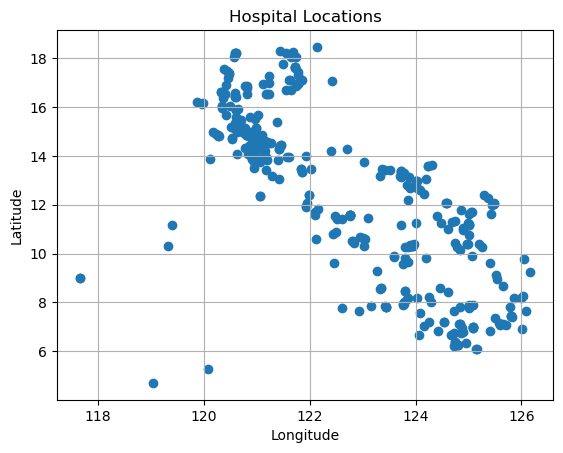

In [17]:
plt.scatter(data['Longitude'], data['Latitude'])
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Hospital Locations')
plt.grid(True)

plt.savefig("hospitals_locations.png")
plt.show()

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 447 entries, 0 to 446
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Name           447 non-null    object 
 1   Latitude       447 non-null    float64
 2   Longitude      447 non-null    float64
 3   Hospital Type  447 non-null    object 
 4   City           87 non-null     object 
 5   Location       447 non-null    object 
dtypes: float64(2), object(4)
memory usage: 21.1+ KB


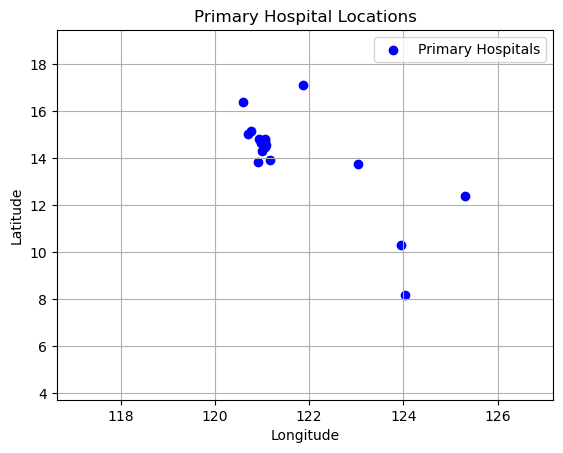

In [18]:
# Filter data to include only primary hospitals
primary_hospitals = data[data['Hospital Type'] == 'Primary']

# Create a scatter plot for primary hospitals
plt.scatter(primary_hospitals['Longitude'], primary_hospitals['Latitude'], color='blue', label='Primary Hospitals')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Primary Hospital Locations')
plt.legend()
plt.grid(True)

# Set appropriate plot limits
plt.xlim(data['Longitude'].min() - 1, data['Longitude'].max() + 1)
plt.ylim(data['Latitude'].min() - 1, data['Latitude'].max() + 1)

plt.savefig("hospitals_locations_primary.png")
plt.show()

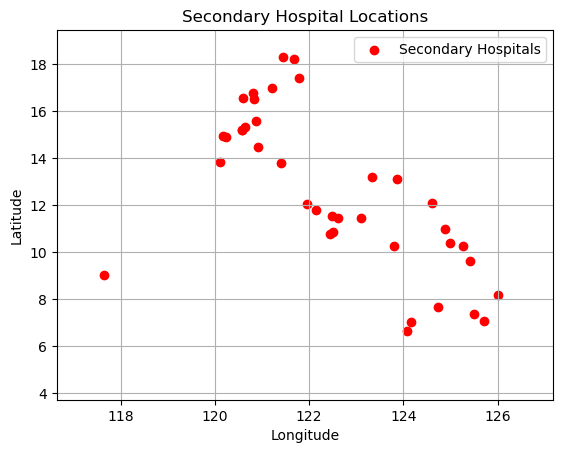

In [19]:
# Filter data to include only secondary hospitals
secondary_hospitals = data[data['Hospital Type'] == 'Secondary']

# Create a scatter plot for secondary hospitals
plt.scatter(secondary_hospitals['Longitude'], secondary_hospitals['Latitude'], color='red', label='Secondary Hospitals')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Secondary Hospital Locations')
plt.legend()
plt.grid(True)

# Set appropriate plot limits
plt.xlim(data['Longitude'].min() - 1, data['Longitude'].max() + 1)
plt.ylim(data['Latitude'].min() - 1, data['Latitude'].max() + 1)

plt.savefig("hospitals_locations_secondary.png")
plt.show()

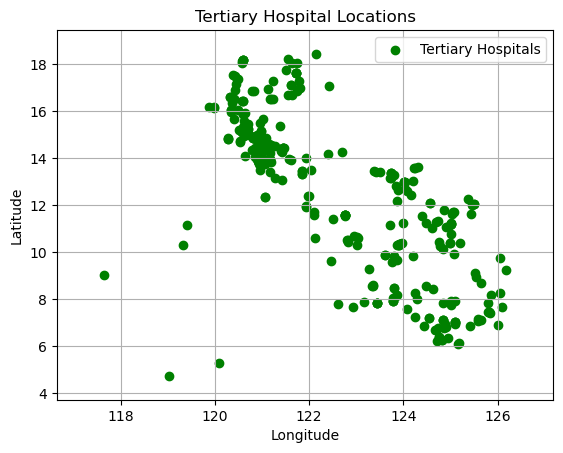

In [14]:
# Filter data to include only tertiary hospitals
tertiary_hospitals = data[data['Hospital Type'] == 'Tertiary']

# Create a scatter plot for tertiary hospitals
plt.scatter(tertiary_hospitals['Longitude'], tertiary_hospitals['Latitude'], color='green', label='Tertiary Hospitals')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Tertiary Hospital Locations')
plt.legend()
plt.grid(True)

# Set appropriate plot limits
plt.xlim(data['Longitude'].min() - 1, data['Longitude'].max() + 1)
plt.ylim(data['Latitude'].min() - 1, data['Latitude'].max() + 1)

plt.savefig("hospitals_locations_tertiary.png")
plt.show()

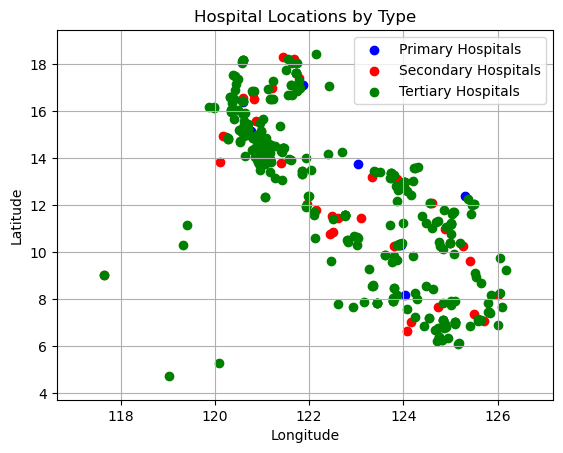

In [15]:
# Filter data for each hospital type
primary_hospitals = data[data['Hospital Type'] == 'Primary']
secondary_hospitals = data[data['Hospital Type'] == 'Secondary']
tertiary_hospitals = data[data['Hospital Type'] == 'Tertiary']

# Create scatter plots for each hospital type
plt.scatter(primary_hospitals['Longitude'], primary_hospitals['Latitude'], color='blue', label='Primary Hospitals')
plt.scatter(secondary_hospitals['Longitude'], secondary_hospitals['Latitude'], color='red', label='Secondary Hospitals')
plt.scatter(tertiary_hospitals['Longitude'], tertiary_hospitals['Latitude'], color='green', label='Tertiary Hospitals')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Hospital Locations by Type')
plt.legend()
plt.grid(True)

# Set appropriate plot limits
plt.xlim(data['Longitude'].min() - 1, data['Longitude'].max() + 1)
plt.ylim(data['Latitude'].min() - 1, data['Latitude'].max() + 1)

plt.savefig("hospitals_locations_by_Type.png")
plt.show()

In [16]:
#PLOTTED CITIES

# Read CSV file
csv_file = "medical_facilities_osm.csv"
hospital_data = pd.read_csv(csv_file)

# List of cities in the National Capital Region (NCR) in the Philippines
ncr_cities_ph = ['Manila', 'Quezon City', 'Caloocan', 'Las Piñas', 'Makati', 'Malabon', 'Mandaluyong', 'Marikina', 'Muntinlupa', 'Navotas', 'Parañaque', 'Pasay', 'Pasig', 'Pateros', 'San Juan', 'Taguig', 'Valenzuela']

# Filter the hospital_data DataFrame to include only NCR cities
hospital_data_ncr = hospital_data[hospital_data['City'].isin(ncr_cities_ph)]

# Filter the hospital_data_ncr DataFrame to include only tertiary hospitals
tertiary_hospitals = hospital_data_ncr[hospital_data_ncr['Hospital Type'] == 'Tertiary']

# Filter the hospital_data_ncr DataFrame to include only primary hospitals
primary_hospitals = hospital_data_ncr[hospital_data_ncr['Hospital Type'] == 'Primary']

# Filter the hospital_data_ncr DataFrame to include only secondary hospitals
secondary_hospitals = hospital_data_ncr[hospital_data_ncr['Hospital Type'] == 'Secondary']

# Define a custom color palette for the cities
custom_colors = ['blue', 'green', 'red', 'orange', 'purple', 'brown', 'pink', 'gray', 'cyan', 'magenta', 'olive', 'teal', 'skyblue', 'gold', 'indigo', 'lime', 'salmon']

# Plot the bar graph for number of tertiary hospitals in NCR cities with custom colors
plt.figure(figsize=(10, 6))
tertiary_hospitals_count = tertiary_hospitals['City'].value_counts()
if tertiary_hospitals_count.empty:
    plt.bar(ncr_cities_ph, [0] * len(ncr_cities_ph), color=custom_colors)
else:
    tertiary_hospitals_count.plot(kind='bar', color=custom_colors[:len(tertiary_hospitals_count)])
plt.xlabel('City')
plt.ylabel('Number of Hospitals')
plt.title('Tertiary Hospitals (NCR)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plot the bar graph for number of primary hospitals in NCR cities with custom colors
plt.figure(figsize=(10, 6))
primary_hospitals_count = primary_hospitals['City'].value_counts()
if primary_hospitals_count.empty:
    plt.bar(ncr_cities_ph, [0] * len(ncr_cities_ph), color=custom_colors)
else:
    primary_hospitals_count.plot(kind='bar', color=custom_colors[:len(primary_hospitals_count)])
plt.xlabel('City')
plt.ylabel('Number of Hospitals')
plt.title('Primary Hospitals (NCR)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plot the bar graph for number of secondary hospitals in NCR cities with custom colors
plt.figure(figsize=(10, 6))
secondary_hospitals_count = secondary_hospitals['City'].value_counts()
if secondary_hospitals_count.empty:
    plt.bar(ncr_cities_ph, [0] * len(ncr_cities_ph), color=custom_colors)
else:
    secondary_hospitals_count.plot(kind='bar', color=custom_colors[:len(secondary_hospitals_count)])
plt.xlabel('City')
plt.ylabel('Number of Hospitals')
plt.title('Secondary Hospitals (NCR)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig("hospitals_number_bar.png")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'medical_facilities_osm.csv'

In [ ]:
#PLOT

# Read CSV file
csv_file = "medical_facilities_osm.csv"
hospital_data = pd.read_csv(csv_file)

# Read GeoJSON file
geojson_file = "medical_facilities_osm.geojson"
geo_data = gpd.read_file(geojson_file)

# Count the number of medical facilities per city from CSV
facilities_per_city = hospital_data.groupby('City').size().reset_index(name='Number of Facilities')

# List of cities in the National Capital Region (NCR) in the Philippines
ncr_cities_ph = ['Manila', 'Quezon City', 'Caloocan', 'Las Piñas', 'Makati', 'Malabon', 'Mandaluyong', 'Marikina', 'Muntinlupa', 'Navotas', 'Parañaque', 'Pasay', 'Pasig', 'Pateros', 'San Juan', 'Taguig', 'Valenzuela']

# Filter the facilities_per_city DataFrame to include only NCR cities
facilities_per_ncr = facilities_per_city[facilities_per_city['City'].isin(ncr_cities_ph)]

# Plot the bar graph for NCR cities
plt.figure(figsize=(10, 6))
plt.bar(facilities_per_ncr['City'], facilities_per_ncr['Number of Facilities'])
plt.xlabel('City')
plt.ylabel('Number of Medical Facilities')
plt.title('Number of Medical Facilities in NCR Cities')
plt.xticks(rotation=45)  # Set rotation to 90 degrees for vertical display
plt.tight_layout()

plt.savefig("hospital_medical_facility_ncr.png")
plt.show()